In [2]:
!pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [2]:
# 1. GENERATE SYNTHETIC FINANCIAL DATA
np.random.seed(42)
n_samples = 10000

data = pd.DataFrame({
    'income': np.random.normal(50000, 15000, n_samples).astype('int'),
    'credit_score': np.random.randint(300, 850, n_samples),
    'debt_to_income': np.random.uniform(0.1, 0.6, n_samples),
    'employment_duration': np.round( np.random.exponential(5, n_samples),2 )  ,
    'housing_status': np.random.choice(['Own', 'Rent', 'Mortgage'], n_samples),
    'loan_amount': np.round( np.random.normal(15000, 5000, n_samples),2)
})

# Define default rules with some noise (Imbalanced class: ~10% default rate)
logit = (-0.0001 * data['income'] - 0.01 * data['credit_score'] + 
         5.0 * data['debt_to_income'] + 0.0001 * data['loan_amount'])
prob = 1 / (1 + np.exp(-logit))
data['is_default'] = np.where(prob > np.percentile(prob, 90), 1, 0)

data.to_csv("data_loan_defaulter.csv", index=False)

In [3]:
df = pd.read_csv("data_loan_defaulter.csv")
df.head()

,income,credit_score,debt_to_income,employment_duration,housing_status,loan_amount,is_default
0,57450,330,0.373063,0.54,Mortgage,19110.21,0
1,47926,427,0.287471,1.54,Own,6676.08,0
2,59715,593,0.211456,8.48,Own,9511.77,0
3,72845,740,0.519618,3.51,Mortgage,15031.08,0
4,46487,687,0.337916,11.93,Mortgage,14856.23,0


--- Value Counts ---
is_default
0    9000
1    1000
Name: count, dtype: int64

--- Percentages ---
is_default
0    90.0
1    10.0
Name: proportion, dtype: float64


C:\Users\hi\AppData\Local\Temp\ipykernel_18644\2660183924.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_default', data=data, palette='Set1')


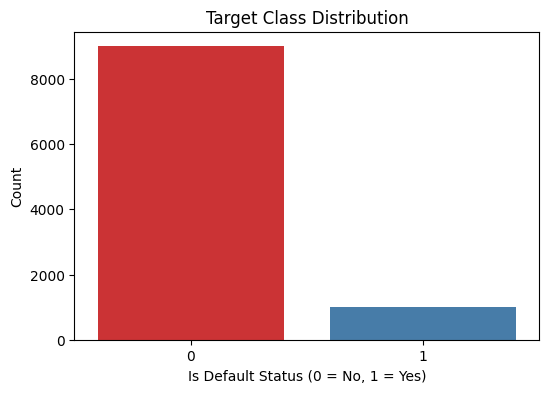

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Print value counts and percentages
print("--- Value Counts ---")
print(data['is_default'].value_counts())

print("\n--- Percentages ---")
print(data['is_default'].value_counts(normalize=True) * 100)

# 2. Plot the count distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='is_default', data=data, palette='Set1')
plt.title('Target Class Distribution')
plt.xlabel('Is Default Status (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()


In [5]:
# 2. PREPROCESSING & ENCODING
# Encode categorical financial variables

le = LabelEncoder()
df['housing_status'] = le.fit_transform(df['housing_status'])

df

,income,credit_score,debt_to_income,employment_duration,housing_status,loan_amount,is_default
0,57450,330,0.373063,0.54,0,19110.21,0
1,47926,427,0.287471,1.54,1,6676.08,0
2,59715,593,0.211456,8.48,1,9511.77,0
3,72845,740,0.519618,3.51,0,15031.08,0
4,46487,687,0.337916,11.93,0,14856.23,0
...,...,...,...,...,...,...,...
9995,69516,794,0.296267,0.24,2,21710.79,0
9996,20024,718,0.522042,9.03,1,12671.28,0
9997,39420,505,0.371190,8.14,2,11826.44,0
9998,57436,617,0.335291,0.76,0,11776.00,0


In [6]:
# Seperate feature and target variables

X = df.drop(columns=['is_default'])
y = df['is_default']

In [7]:
X

,income,credit_score,debt_to_income,employment_duration,housing_status,loan_amount
0,57450,330,0.373063,0.54,0,19110.21
1,47926,427,0.287471,1.54,1,6676.08
2,59715,593,0.211456,8.48,1,9511.77
3,72845,740,0.519618,3.51,0,15031.08
4,46487,687,0.337916,11.93,0,14856.23
...,...,...,...,...,...,...
9995,69516,794,0.296267,0.24,2,21710.79
9996,20024,718,0.522042,9.03,1,12671.28
9997,39420,505,0.371190,8.14,2,11826.44
9998,57436,617,0.335291,0.76,0,11776.00


In [8]:
y

0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: is_default, Length: 10000, dtype: int64

In [9]:
# Lets find 2 test data point: idx=2, 18
print(list(X.loc[18]))
print(y[18])

[36379.0, 422.0, 0.4856183333089249, 16.55, 0.0, 13593.86]
1


In [10]:
# Stratified split to preserve the minority class (default loans) ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [11]:
# Scale features (Mandatory for Logistic Regression to converge properly)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
print(list(X_train.loc[0])) # original
print(X_train_scaled[0])    # scaled

[57450.0, 330.0, 0.3730629761844672, 0.54, 0.0, 19110.21]
[0.6302352  1.67288194 0.87581239 1.7910558  1.23041156 0.77836888]


# A) MODEL 1: LOGISTIC REGRESSION (BALANCED)

In [28]:
# class_weight='balanced' automatically adjusts weights inversely proportional to class frequencies
model_lr = LogisticRegression(class_weight='balanced', random_state=42)
model_lr.fit(X_train_scaled, y_train)

y_pred = model_lr.predict(X_test_scaled)
y_proba = model_lr.predict_proba(X_test_scaled)[:, 1]

print("Classification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, normalize='true').round(2)
print("Confusion matrix:\n", cm*100)


print("\nROC-AUC Score:",roc_auc_score(y_test, y_proba).round(4))

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99      1800
           1       0.86      1.00      0.93       200

    accuracy                           0.98      2000
   macro avg       0.93      0.99      0.96      2000
weighted avg       0.99      0.98      0.98      2000

Confusion matrix:
 [[ 98.   2.]
 [  0. 100.]]

ROC-AUC Score: 1.0


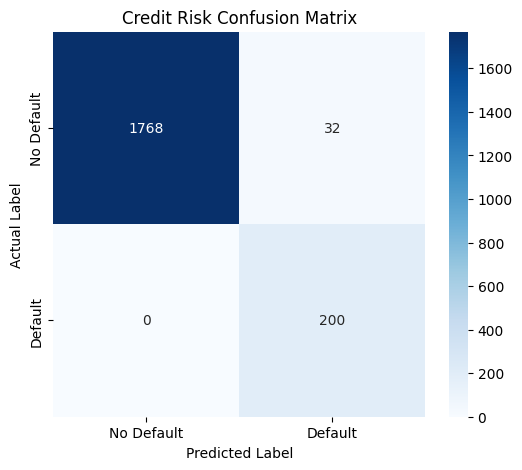

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the raw matrix values
cm = confusion_matrix(y_test, y_pred)

# Plotting the matrix visually
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Default', 'Default'], 
            yticklabels=['No Default', 'Default'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Credit Risk Confusion Matrix')
plt.show()


### 📊 Confusion Matrix Breakdown

A confusion matrix breaks down predictions into four critical quadrants:


| | **Predicted Non-Default (0)** | **Predicted Default (1)** |
| :--- | :--- | :--- |
| **Actual Non-Default (0)** | **True Negative (TN):** <br> Good loans approved | **False Positive (FP):** <br> Good customer rejected *(Lost revenue)* |
| **Actual Default (1)** | **False Negative (FN):** <br> Defaulted loan approved *(Financial loss)* | **True Positive (TP):** <br> Risky borrower blocked |


#### Question: Which mistake costs your business more: 
- a False Negative (missing a default) or
- a False Positive (blocking a good user)?

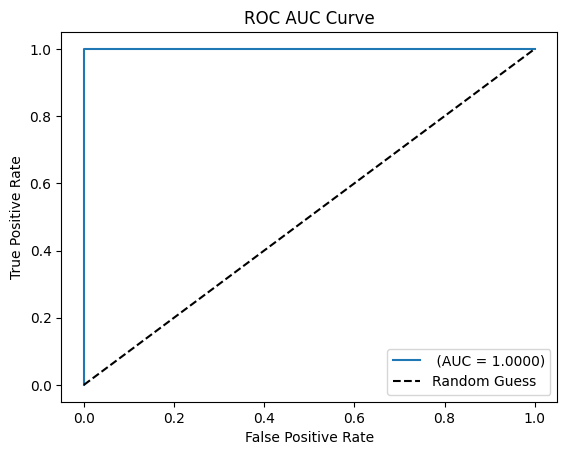

In [30]:
from sklearn.metrics import roc_curve, auc

# Calculate rates
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot manually
plt.plot(fpr, tpr, label=f' (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess') # Diagonal baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Curve')
plt.legend(loc='lower right')
plt.show()


In [44]:
# Lets find 2 test data point: idx=2, 18
print(list(X.loc[18]))
print(y[18])

[36379.0, 422.0, 0.4856183333089249, 16.55, 0.0, 13593.86]
1


In [38]:
# lets test on one data point:
data = [[59715, 593, 0.211456, 8.48, 1, 9511.77], # idx=2, Actual is y=0
        [36379.0, 422.0, 0.4856183333089249, 16.55, 0.0, 13593.86], # idx=18, actual y=1
       ]

data_scaled = scaler.transform(data)
print(model_lr.predict(data_scaled))

[0 1]


C:\Users\hi\Desktop\projects\python_projects\tutorial\tut_tensorflow\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# B) DECISION TREE (BALANCED)

In [31]:
# max_depth=5 prevents the tree from over-fitting the dataset
model_dt = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)
model_dt.fit(X_train, y_train) # Trees do not strictly require feature scaling

y_pred = model_dt.predict(X_test)
y_proba = model_dt.predict_proba(X_test)[:, 1]

print("Classification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, normalize='true').round(2)
print("Confusion matrix:\n", cm*100)


print("\nROC-AUC Score:",roc_auc_score(y_test, y_proba).round(4))

Classification report:
               precision    recall  f1-score   support

           0       0.99      0.91      0.95      1800
           1       0.52      0.93      0.67       200

    accuracy                           0.91      2000
   macro avg       0.76      0.92      0.81      2000
weighted avg       0.94      0.91      0.92      2000

Confusion matrix:
 [[91.  9.]
 [ 7. 93.]]

ROC-AUC Score: 0.9551


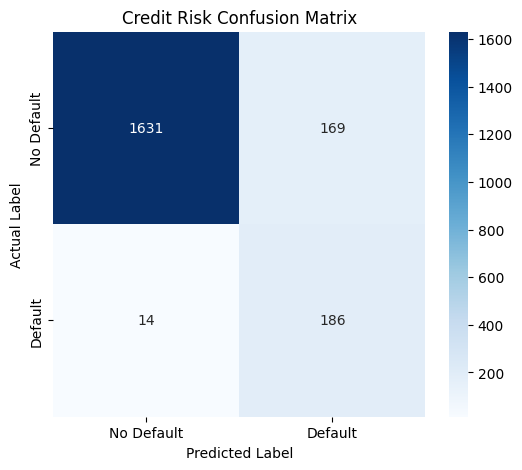

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the raw matrix values
cm = confusion_matrix(y_test, y_pred)

# Plotting the matrix visually
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Default', 'Default'], 
            yticklabels=['No Default', 'Default'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Credit Risk Confusion Matrix')
plt.show()


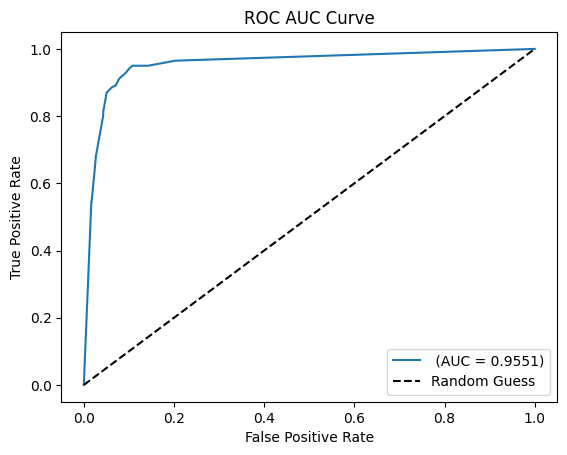

In [33]:
from sklearn.metrics import roc_curve, auc

# Calculate rates
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot manually
plt.plot(fpr, tpr, label=f' (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess') # Diagonal baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Curve')
plt.legend(loc='lower right')
plt.show()


In [39]:
# lets test on one data point:
data = [[59715, 593, 0.211456, 8.48, 1, 9511.77], # idx=2, Actual is y=0
        [36379.0, 422.0, 0.4856183333089249, 16.55, 0.0, 13593.86], # idx=18, actual y=1
       ]

print(model_dt.predict(data))

[0 1]


C:\Users\hi\Desktop\projects\python_projects\tutorial\tut_tensorflow\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# C) TRAIN LIGHTGBM CLASSIFIER

In [35]:

# scale_pos_weight handles class imbalance by penalising minority class errors heavily
ratio = (len(y_train) - sum(y_train)) / sum(y_train)

model_lgb = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    scale_pos_weight=ratio,
    learning_rate=0.05,
    n_estimators=200,
    random_state=42
)

model_lgb.fit(X_train, y_train)

# 4. EVALUATE MODEL
y_pred = model_lgb.predict(X_test)
y_proba = model_lgb.predict_proba(X_test)[:, 1]

print("Classification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, normalize='true').round(2)
print("Confusion matrix:\n", cm*100)


print("\nROC-AUC Score:",roc_auc_score(y_test, y_proba).round(4))

[LightGBM] [Info] Number of positive: 800, number of negative: 7200
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000368 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1273
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.100000 -> initscore=-2.197225
[LightGBM] [Info] Start training from score -2.197225
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      1800
           1       0.89      0.96      0.93       200

    accuracy                           0.98      2000
   macro avg       0.94      0.98      0.96      2000
weighted avg       0.99      0.98      0.99      2000

Confusion matrix:
 [[99.  1.]
 [ 4. 96.]]

ROC-AUC Score: 0.9986


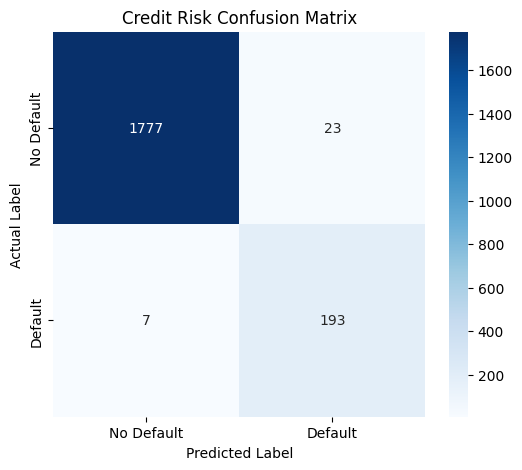

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the raw matrix values
cm = confusion_matrix(y_test, y_pred)

# Plotting the matrix visually
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Default', 'Default'], 
            yticklabels=['No Default', 'Default'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Credit Risk Confusion Matrix')
plt.show()


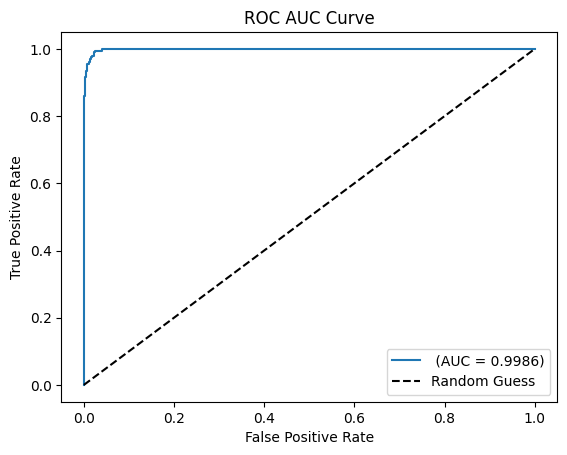

In [37]:
from sklearn.metrics import roc_curve, auc

# Calculate rates
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot manually
plt.plot(fpr, tpr, label=f' (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess') # Diagonal baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Curve')
plt.legend(loc='lower right')
plt.show()


In [40]:
# lets test on one data point:
data = [[59715, 593, 0.211456, 8.48, 1, 9511.77], # idx=2, Actual is y=0
        [36379.0, 422.0, 0.4856183333089249, 16.55, 0.0, 13593.86], # idx=18, actual y=1
       ]

print(model_lgb.predict(data))

[0 1]


# Interpretation

These results suggest that our dataset is **very well separated**, and all three models are performing strongly. 

However, there are some important differences.

---

# 1. Logistic Regression

### Classification Report

| Metric    | Class 0 | Class 1 |
| --------- | ------- | ------- |
| Precision | 1.00    | 0.86    |
| Recall    | 0.98    | 1.00    |
| F1-Score  | 0.99    | 0.93    |

### Confusion Matrix

```
          Predicted
          0     1
Actual 0  98    2
Actual 1   0   100
```

Interpretation:

* Detected **all fraud cases (Recall = 1.00)**.
* No fraud case was missed.
* Only 2 legitimate transactions were incorrectly flagged as fraud.
* Excellent balance between precision and recall.

### ROC-AUC = 1.0

This means the model perfectly separates positive and negative classes.

A ROC-AUC of exactly 1.0 is unusual in real-world datasets and often indicates:

* Extremely clean synthetic data
* Very predictive features
* Possible data leakage (worth checking)

---

# 2. Decision Tree

### Classification Report

| Metric    | Class 0 | Class 1 |
| --------- | ------- | ------- |
| Precision | 0.99    | 0.52    |
| Recall    | 0.91    | 0.93    |
| F1        | 0.95    | 0.67    |

### Confusion Matrix

```
          Predicted
          0     1
Actual 0  91    9
Actual 1   7   93
```

Interpretation:

* Missed 7 fraud cases.
* Incorrectly flagged 9 normal transactions as fraud.
* Precision for fraud is only 52%.

This means:

> When the model predicts fraud, it is correct only about half the time.

This would create many false alarms in production.

### ROC-AUC = 0.955

Still very good, but much lower than Logistic Regression.

---

# 3. Gradient Boosting (LightGBM)

### Classification Report

| Metric    | Class 0 | Class 1 |
| --------- | ------- | ------- |
| Precision | 1.00    | 0.89    |
| Recall    | 0.96    | 0.96    |
| F1        | 0.99    | 0.93    |

### Confusion Matrix

```
          Predicted
          0     1
Actual 0  99    1
Actual 1   4   96
```

Interpretation:

* Missed 4 fraud cases.
* Only 1 false alarm.
* Very strong balance between precision and recall.

### ROC-AUC = 0.9986

Nearly perfect.

---

# Comparing Models

| Metric          | Logistic Regression | Decision Tree | LightGBM |
| --------------- | ------------------- | ------------- | -------- |
| Accuracy        | 98%                 | 91%           | 98%      |
| Fraud Precision | 86%                 | 52%           | 89%      |
| Fraud Recall    | 100%                | 93%           | 96%      |
| Fraud F1        | 93%                 | 67%           | 93%      |
| ROC-AUC         | 1.0000              | 0.9551        | 0.9986   |

---

# Which Model is Best?

### If missing fraud is unacceptable

Choose **Logistic Regression**.

Why?

* Recall = 100%
* No fraud cases missed
* Excellent AUC
* Simple and interpretable

---

### If you want the best overall predictive model

Choose **LightGBM**.

Why?

* Highest fraud precision (89%)
* Very high recall (96%)
* Almost perfect AUC
* Usually scales better on larger datasets

---

### Decision Tree

Not recommended here because:

* Much lower precision
* Much lower F1 score
* More false alarms
* More missed frauds

---

# Something to Investigate

Your Logistic Regression is performing almost perfectly.

For a dataset with:

* 10,000 samples
* Only 6 features
* Class imbalance (90/10)

A ROC-AUC of 1.0 is suspiciously good.

I would verify:

1. No target leakage.
2. Train-test split happened before preprocessing.
3. No feature is derived from the target.
4. No duplicate rows exist across train and test.

If this is a teaching dataset (e.g., synthetic fraud data), then these results are completely plausible.

### Summary

> Logistic Regression performed surprisingly well, achieving 98% accuracy and a perfect ROC-AUC score of 1.0. This indicates that the classes are almost linearly separable. LightGBM achieved similar performance, demonstrating that more complex models do not always outperform simpler models. The Decision Tree showed lower precision and F1-score, suggesting that a single tree was unable to generalize as effectively as Logistic Regression or Gradient Boosting. This comparison highlights an important machine learning lesson: simpler models should always be tested before moving to more complex algorithms.
